# Here we look at global means and seasonality of convex hull membership

In [1]:
1

1

In [2]:
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as crs

import pandas as pd
import geopandas as gpd
import seaborn as sns
import os

## First let's build the convex hull
grab the data from Valente

In [3]:
chla_df = pd.read_csv('data/insitudb_chla_V3.tab',skiprows=28, delimiter='\t')
chla_df = chla_df.set_index('ID (idx)')

In [4]:
rrs_df = pd.read_csv('data/insitudb_rrs_satbands6_V3.tab',skiprows=159, delimiter='\t')
rrs_df = rrs_df.set_index('ID (idx)')

In [5]:
rrs_df.iloc[:,np.arange(28,46,2)].median(axis=0)

Lambda [nm] (assigned to MOD1)    412.4
Lambda [nm] (assigned to MOD2)    442.1
Lambda [nm] (assigned to MOD3)    490.0
Lambda [nm] (assigned to MOD4)    530.6
Lambda [nm] (assigned to MOD5)    551.1
Lambda [nm] (assigned to MOD6)    667.7
Lambda [nm] (assigned to MOD7)    681.0
Lambda [nm] (assigned to MOD8)    748.0
Lambda [nm] (assigned to MOD9)    869.9
dtype: float64

In [6]:
wls = np.array([412.4, 442.1, 490. , 510, 555, 667.7, 681. , 748. , 869.9])

In [7]:
rrs_subset = rrs_df.iloc[:,np.arange(27,45,2)]

In [8]:
rrs_subset.columns = rrs_df.iloc[:,np.arange(28,46,2)].median(axis=0).values

In [9]:
rrs_subset.head()

,412.4,442.1,490.0,530.6,551.1,667.7,681.0,748.0,869.9
ID (idx),,,,,,,,,
1,0.005377,0.004674,0.005059,NaN,NaN,0.000432,NaN,NaN,NaN
20,0.004338,0.003396,0.003545,NaN,NaN,0.000222,NaN,NaN,NaN
23,0.004308,0.003106,0.003106,NaN,NaN,0.000204,NaN,NaN,NaN
24,0.011927,0.011094,0.010550,NaN,NaN,0.002419,NaN,NaN,NaN
67,0.006443,0.005456,0.004668,NaN,NaN,0.000139,0.000231,NaN,NaN


In [10]:
# trying now with the original 6 wv dataset from MODIS
valente_df = pd.merge(rrs_subset,chla_df, right_index=True, left_index=True)

In [11]:
len(valente_df)

3840

In [12]:
valente_df.head()

,412.4,442.1,490.0,530.6,551.1,667.7,681.0,748.0,869.9,Date/Time,...,"Chl a [mg/m**3] (Chlorophyll a, fluorometric o...)","Depth water [m] (water depth from ETOPO1, if >...)",Comment (chla_hplc_dataset),Comment (chla_hplc_subdataset),Comment (chla_hplc_contributor),Comment (chla_fluor_dataset),Comment (chla_fluor_subdataset),Comment (chla_fluor_contributor),QF time (1 if observation without time...),QF Chl (1 if observation as unknown c...)
ID (idx),,,,,,,,,,,,,,,,,,,,,
1,0.005377,0.004674,0.005059,NaN,NaN,0.000432,NaN,NaN,NaN,1997-01-02T12:48,...,1.43685,423,palmer,palmer_chl_seasons,Maria_Vernet&Oscar_Schofield,nomad,nomad_palmer_lter,Raymond_Smith,NaN,NaN
20,0.004338,0.003396,0.003545,NaN,NaN,0.000222,NaN,NaN,NaN,1997-01-06T13:16,...,1.60740,423,NaN,NaN,NaN,nomad,nomad_palmer_lter,Raymond_Smith,NaN,NaN
23,0.004308,0.003106,0.003106,NaN,NaN,0.000204,NaN,NaN,NaN,1997-01-06T14:22,...,1.13250,108,NaN,NaN,NaN,nomad,nomad_palmer_lter,Raymond_Smith,NaN,NaN
24,0.011927,0.011094,0.010550,NaN,NaN,0.002419,NaN,NaN,NaN,1997-01-06T14:55,...,0.87100,73,NaN,NaN,NaN,nomad,nomad_palmer_lter,Raymond_Smith,NaN,NaN
67,0.006443,0.005456,0.004668,NaN,NaN,0.000139,0.000231,NaN,NaN,1997-01-09T21:26,...,0.19300,4332,NaN,NaN,NaN,nomad,nomad_kaiyo9710,Marlon_Lewis,NaN,NaN


In [13]:
valente_df['chla'] = valente_df['Chl a [mg/m**3] (High Performance Liquid Chrom...)'].fillna(valente_df['Chl a [mg/m**3] (Chlorophyll a, fluorometric o...)'])

In [14]:
# valente_df.to_csv('data/valente_chla_rrs_v3.csv')

In [15]:
gdf = gpd.GeoDataFrame(
    valente_df, geometry=gpd.points_from_xy(valente_df.Longitude, valente_df.Latitude), crs="EPSG:4326"
)

#### Now we build the ConvexHull

In [16]:
def in_hull(p, hull):
    """
    Test if points in `p` are in `hull`

    `p` should be a `NxK` coordinates of `N` points in `K` dimensions
    `hull` is either a scipy.spatial.Delaunay object or the `MxK` array of the 
    coordinates of `M` points in `K`dimensions for which Delaunay triangulation
    will be computed
    """
    from scipy.spatial import Delaunay
    if not isinstance(hull,Delaunay):
        hull = Delaunay(hull)

    return hull.find_simplex(p)>=0

# this was the original distance approach in 2D
x = np.nanmax([valente_df[442.1],valente_df[490.0]],axis=0)
y = valente_df[551.1].values
pts = np.array([x,y])
pts = pts.T[(~np.isnan(pts)).all(axis=0)]

# the 3D approach
# pts = np.array([valente_df[442.1],valente_df[490.0],valente_df[551.1]])
# pts = pts.T[(~np.isnan(pts)).all(axis=0)]

# go through the points, if they don't have a neighbor within 30% of their value then throw them out, then make a convex hull

import math
def get_dist(a,b):
  # return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
    return(np.linalg.norm(a-b))

np_list = []
for i in range(len(pts)):
    dist = math.inf #(infinity)
    npidx = 0
    for j in range(len(pts)):
       d = get_dist(pts[i],pts[j])
       if d<dist and d!=0: # to avoid the same point
          dist = d
          npidx = j
    np_list.append(dist)

mean_val = pts.mean(axis=1)

dist_ratio = np_list/mean_val
dist_ratio[dist_ratio > 0.2]

/tmp/ipykernel_181/3767356168.py:17: RuntimeWarning: All-NaN axis encountered
  x = np.nanmax([valente_df[442.1],valente_df[490.0]],axis=0)


array([0.31491375, 0.81345096, 0.21525662, 0.22311772, 0.26597213,
       0.23154527, 0.22894162, 0.24662609, 1.28377256, 3.48624781])

Inspect the excluded points

/tmp/ipykernel_181/861726583.py:13: RuntimeWarning: All-NaN axis encountered
  ax.scatter(x = np.nanmax([valente_df[442.1],valente_df[490.0]],axis=0),


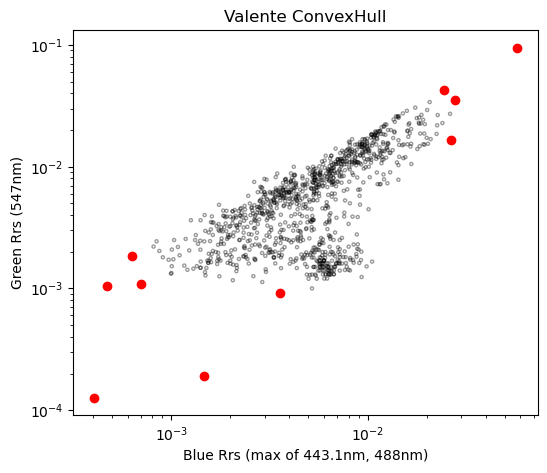

In [17]:
skip_num = 1
fig, ax = plt.subplots(figsize=(6,5))

# hb = ax.hexbin(x = np.max([modis_global.Rrs_443.values.flatten()[::skip_num],
#                        modis_global.Rrs_488.values.flatten()[::skip_num]],axis=0), 
#            y = modis_global.Rrs_555.values.flatten()[::skip_num],
#           yscale='log',xscale='log',
#          gridsize=30,
#           bins='log',
#          cmap='Blues')
# fig.colorbar(hb)

ax.scatter(x = np.nanmax([valente_df[442.1],valente_df[490.0]],axis=0),
           y = valente_df[551.1], facecolor='none', edgecolor='k', alpha=0.4, label='Valente',s=5)

from scipy.spatial import ConvexHull, convex_hull_plot_2d

hull = ConvexHull(pts[dist_ratio < 0.2])

# for simplex in hull.simplices:
#     ax.plot(pts[dist_ratio < 0.2][simplex, 0], pts[dist_ratio < 0.2][simplex, 1], 'k--')


ax.scatter(pts[dist_ratio>.2][:,0], pts[dist_ratio>.2][:,1],c='red')
# ax.scatter(np.nanmax([pts[dist_ratio>.3][:,0], pts[dist_ratio>.3][:,1]],axis=0),pts[dist_ratio>.3][:,2],c='red')

# ax.set_ylim(0.00015,0.07)
# ax.set_xlim(0.00015,0.07)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Blue Rrs (max of 443.1nm, 488nm)')
ax.set_ylabel('Green Rrs (547nm)')
ax.set_title('Valente ConvexHull')

# plt.savefig('figs/modis_winter_valente_density.png',dpi=600)

plt.show()

In [18]:
auth = earthaccess.login(persist=True)

## Pull in MODIS data via earth data access

In [19]:
tspan = ("2019-05-05", "2020-05-05")
# tspan = ("2018-02-20", "2019-02-20")

results = earthaccess.search_data(
    # short_name="PACE_OCI_L3M_RRS",
    short_name="MODISA_L3m_RRS",
    temporal=tspan,
    # bounding_box=bbox,
    # cloud_cover=clouds,
)
len(results)

14016

In [20]:
rrs_412 = []
rrs_443 = []
rrs_488 = []
rrs_531 = []
rrs_555 = []
for i in range(int(len(results))):
    item = results[i]['umm']['RelatedUrls'][1]['URL']
    if 'DAY' in item:
        if '9km' in item:
            if 'Rrs_' in item:
                if 'Rrs_412' in item:
                    rrs_412.append(i)
                if 'Rrs_443' in item:
                    rrs_443.append(i)
                if 'Rrs_488' in item:
                    rrs_488.append(i)
                if 'Rrs_531' in item:
                    rrs_531.append(i)
                if 'Rrs_555' in item:
                    rrs_555.append(i)

In [21]:
len(rrs_412),len(rrs_443),len(rrs_488),len(rrs_531),len(rrs_555)

(367, 367, 367, 367, 367)

## check if the points from MODIS are within the Hull

In [90]:
from scipy.spatial import Delaunay

native_ids = [] 
datetimes = []
inside = []
outside = []
valid_pixel_count = []

count_map = np.zeros([2160,4320])
nonnan_map = np.zeros([2160,4320])

count_map_ndims = []
nonnan_map_ndims = []

step_count = 0

pts = np.array([np.max([valente_df[442.1],valente_df[490.0]],axis=0),valente_df[551.1]])
# pts = np.array([valente_df[442.1],valente_df[490.0],valente_df[551.1]])
pts = pts.T[(~np.isnan(pts)).all(axis=0)]

hull =  Delaunay(pts[dist_ratio < 0.2])

for i in range(len(rrs_443)):
    native_ids.append(results[rrs_443[i]]['meta']['native-id'])
    datetimes.append(pd.to_datetime(results[rrs_443[i]]['meta']['native-id'].split('.')[1][:8]))

    paths = earthaccess.download([results[rrs_443[i]], results[rrs_488[i]], results[rrs_555[i]]], local_path="data_tmp")
    ds = xr.open_dataset(paths[0])
    ds2 = xr.open_dataset(paths[1])
    ds3 = xr.open_dataset(paths[2])
    
    ds['Rrs_488'] = ds2.Rrs_488
    ds['Rrs_555'] = ds3.Rrs_555
    
    modis_pts = np.array([np.max([ds.Rrs_443.values.flatten(),ds.Rrs_488.values.flatten()],axis=0),ds.Rrs_555.values.flatten()]).T
    print('data formatted')

    bool_mask = (~np.isnan(modis_pts)).all(axis=1)
    
    valid_pixel_count.append(np.count_nonzero(bool_mask))

    points_in_hull = np.zeros(9331200, dtype=bool)
    points_in_hull[bool_mask] = hull.find_simplex(modis_pts[bool_mask])>=0
    print('hull analysis done')
    
    count_map += points_in_hull.reshape(ds.Rrs_443.shape)
    count_map_ndims.append(points_in_hull.reshape(ds.Rrs_443.shape))
    nonnan_map_ndims.append((~np.isnan(modis_pts)).all(axis=1).astype(int).reshape(ds.Rrs_443.shape).astype(np.int8))

    nonnan_map += (~np.isnan(modis_pts)).all(axis=1).astype(int).reshape(ds.Rrs_443.shape)

    boolie, count = np.unique(points_in_hull[(~np.isnan(modis_pts)).all(axis=1)],return_counts=True)
    if boolie[0]:
        in_count = count[0]
        out_count = count[1]
    else:
        in_count = count[1]
        out_count = count[0]
    inside.append(in_count)
    outside.append(out_count)

    for p in paths:
        os.remove(p)
    
    step_count  += 1
    # if step_count > 3:
    #     break
    print(step_count)

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

data formatted
hull analysis done
1


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

...

data formatted
hull analysis done
366


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

data formatted
hull analysis done
367


In [91]:
1

1

## Pull in PACE data via earth data access

In [19]:
tspan = ("2019-05-05", "2020-05-05")
# tspan = ("2018-02-20", "2019-02-20")

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_RRS",
    # short_name="MODISA_L3m_RRS",
    temporal=tspan,
    # bounding_box=bbox,
    # cloud_cover=clouds,
)
len(results)

14016

In [17]:
id_list = []
for i in range(len(results)):
    # if 'L3m.8D.RRS.V3_0.Rrs.0p1deg' in results[i]['meta']['native-id']:
        id_list.append(i)
len(id_list)

0

### now check if the points from PACE are within the Hull

This is applied to a full year of data and thus takes a long time

In [22]:
from scipy.spatial import Delaunay

native_ids = [] 
datetimes = []
inside = []
outside = []
valid_pixel_count = []

count_map = np.zeros([1800,3600])
nonnan_map = np.zeros([1800,3600])

count_map_ndims = []
nonnan_map_ndims = []

step_count = 0

pts = np.array([valente_df[442.1],valente_df[490.0],valente_df[551.1]])
pts = pts.T[(~np.isnan(pts)).all(axis=0)]

hull =  Delaunay(pts[dist_ratio < 0.2])

for i in id_list:
    native_ids.append(results[i]['meta']['native-id'])
    datetimes.append(pd.to_datetime(results[i]['meta']['native-id'].split('.')[1][:8]))
    
    # paths = earthaccess.open([results[i]])
    # ds = xr.open_mfdataset(paths)

    paths = earthaccess.download(results[i], local_path="data_tmp")
    print('file downloaded')
    ds = xr.open_dataset(paths[0])
    
    # pace_pts = np.array([np.max([ds.Rrs[:,:,42].values.flatten(),ds.Rrs[:,:,60].values.flatten()],axis=0),ds.Rrs[:,:,84].values.flatten()]).T
    pace_pts = np.array([ds.Rrs[:,:,42].values.flatten(),ds.Rrs[:,:,60].values.flatten(),ds.Rrs[:,:,84].values.flatten()]).T
    
    # pace_pts = np.array([ds.Rrs[:,:,42].values.flatten(),ds.Rrs[:,:,60].values.flatten(),ds.Rrs[:,:,84].values.flatten()]).T
    print('data formatted')

    bool_mask = (~np.isnan(pace_pts)).all(axis=1)
    
    valid_pixel_count.append(np.count_nonzero(bool_mask))

    points_in_hull = np.zeros(6480000, dtype=bool)
    points_in_hull[bool_mask] = hull.find_simplex(pace_pts[bool_mask])>=0
    print('hull analysis done')
    
    count_map += points_in_hull.reshape(ds.Rrs.shape[:2])
    count_map_ndims.append(points_in_hull.reshape(ds.Rrs.shape[:2]))
    nonnan_map_ndims.append((~np.isnan(pace_pts)).all(axis=1).astype(int).reshape(ds.Rrs.shape[:2]))

    nonnan_map += (~np.isnan(pace_pts)).all(axis=1).astype(int).reshape(ds.Rrs.shape[:2])

    boolie, count = np.unique(points_in_hull[(~np.isnan(pace_pts)).all(axis=1)],return_counts=True)
    if boolie[0]:
        in_count = count[0]
        out_count = count[1]
    else:
        in_count = count[1]
        out_count = count[0]
    inside.append(in_count)
    outside.append(out_count)

    os.remove(paths[0])
    
    step_count  += 1
    # if step_count > 3:
    #     break
    print(step_count)

NameError: name 'id_list' is not defined

# now analyze

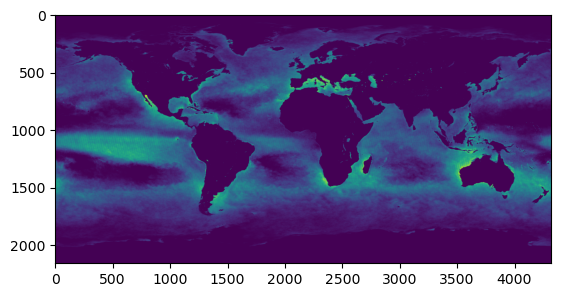

In [92]:
cb = plt.imshow(count_map)

ValueError: x and y must have same first dimension, but have shapes (4,) and (3,)

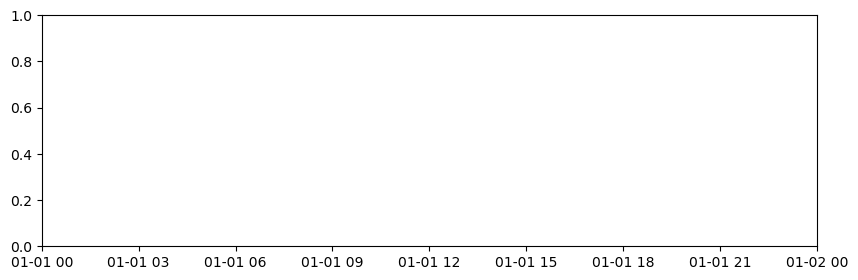

In [25]:
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(datetimes, np.array(inside)/np.array(valid_pixel_count),marker='o')

ax.set_ylim(0,1)
plt.show()

In [76]:
# count_map[count_map == 0] = np.nan

AttributeError: 'Dataset' object has no attribute 'Rrs'

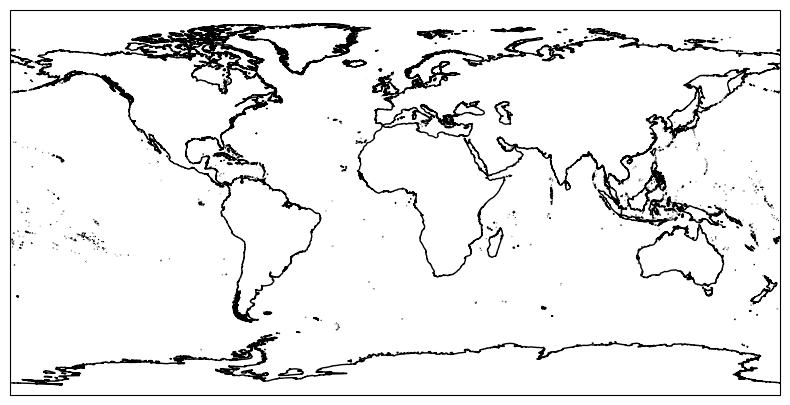

In [77]:
fig, ax = plt.subplots(figsize=(12,5), subplot_kw=dict(projection=crs.PlateCarree()))
ax.coastlines(resolution='10m')
# ax.set_ylim(34,45)
# ax.set_xlim(-80,-60)

ds.Rrs[:,:,40].plot(ax=ax, x='lon', y='lat', cmap='viridis')

gl = ax.gridlines(draw_labels=True)

# plt.savefig('figs/440nm_northwest_atlantic_pace.png',dpi=300)

plt.show()

/tmp/ipykernel_181/3377128919.py:3: RuntimeWarning: invalid value encountered in divide
  cbar = plt.imshow(count_map/nonnan_map)


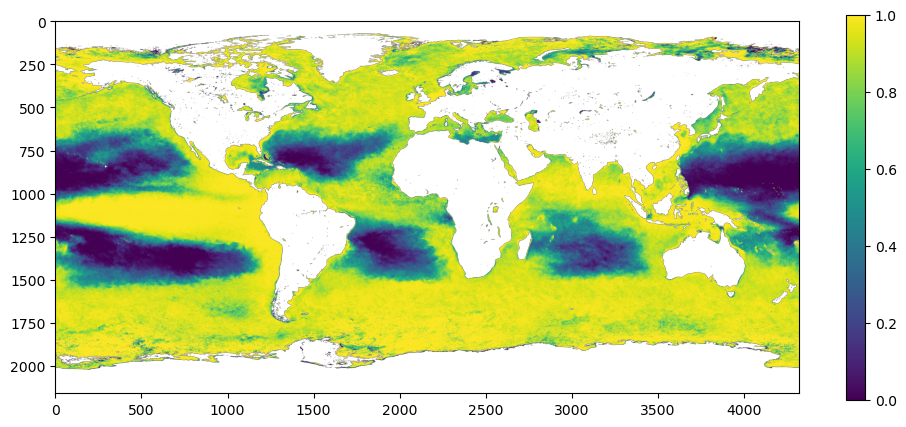

In [93]:
fig, ax = plt.subplots(figsize=(12,5))

cbar = plt.imshow(count_map/nonnan_map)
plt.colorbar(cbar)

In [94]:
# ds['ones'] = (('lat', 'lon'), np.ones(ds.Rrs.shape[:-1]))
ds['ones'] = (('lat', 'lon'), np.ones(ds.Rrs_443.shape))

In [95]:
ds['count_map_normalized'] = (('lat', 'lon'), count_map/nonnan_map)

/tmp/ipykernel_181/1700129919.py:1: RuntimeWarning: invalid value encountered in divide
  ds['count_map_normalized'] = (('lat', 'lon'), count_map/nonnan_map)


<Axes: ylabel='Proportion'>

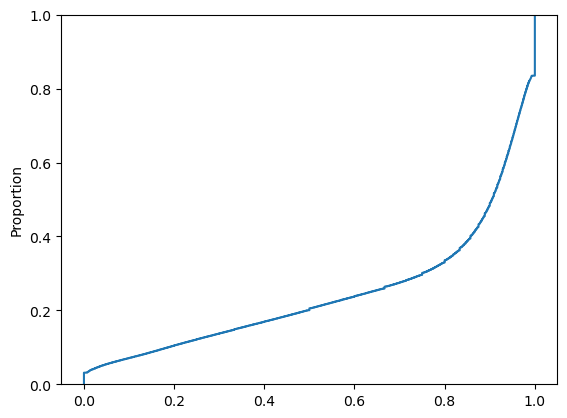

In [96]:
# plt.hist((ds['count_map_normalized'].values.flatten()))
sns.ecdfplot((ds['count_map_normalized'].values.flatten()))
plt.show()

<Axes: ylabel='Proportion'>

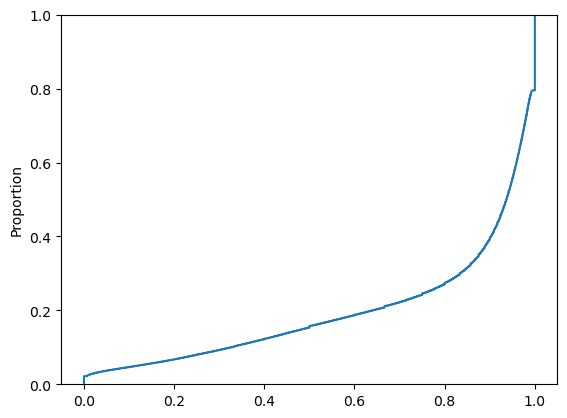

In [40]:
# plt.hist((ds['count_map_normalized'].values.flatten()))
sns.ecdfplot((ds['count_map_normalized'].values.flatten()))

In [1]:
1-.2439, 1-0.3467

(0.7561, 0.6533)

In [97]:
# for MODIS at two bands it was 0.2439 and at 3 bands it was 0.3467
1-np.nanmean(ds['count_map_normalized'].values.flatten())

0.2438858516217579

In [51]:
# for PACE at two bands this was 0.1186 and at 3 bands it was 0.1935
1-np.nanmean(ds['count_map_normalized'].values.flatten())

0.3466772841928226

In [98]:
ds['nonnan_map'] = (('lat', 'lon'), nonnan_map)

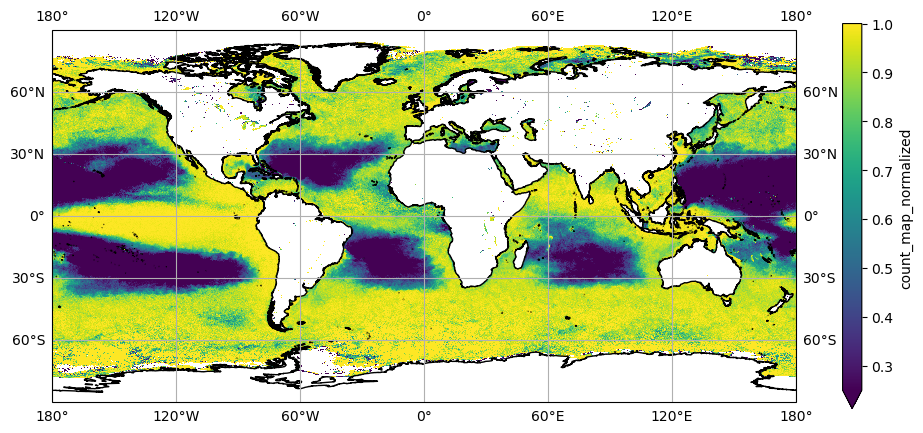

In [99]:
fig, ax = plt.subplots(figsize=(12,5), subplot_kw=dict(projection=crs.PlateCarree()))
ax.coastlines(resolution='10m')
# ax.set_ylim(34,45)
# ax.set_xlim(-80,-60)

ds.count_map_normalized.plot(ax=ax, x='lon', y='lat', cmap='viridis', vmin=0.25,vmax=1)

gl = ax.gridlines(draw_labels=True)

# plt.savefig('figs/440nm_northwest_atlantic_pace.png',dpi=300)

plt.show()

In [100]:
cm = plt.get_cmap("viridis")
cm.set_bad("red", alpha=0)

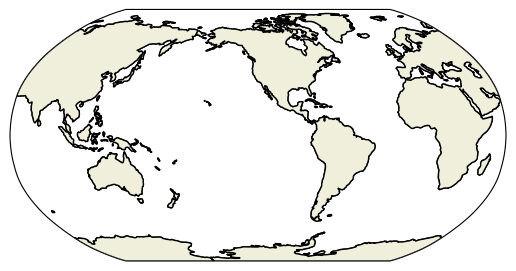

In [101]:
import cartopy as cart

ax = plt.axes(projection=crs.Robinson(central_longitude=-120))
ax.coastlines()
ax.add_feature(cart.feature.LAND, zorder=100, edgecolor='k')

In [102]:
! pip install cmocean

  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)


In [103]:
import cmocean

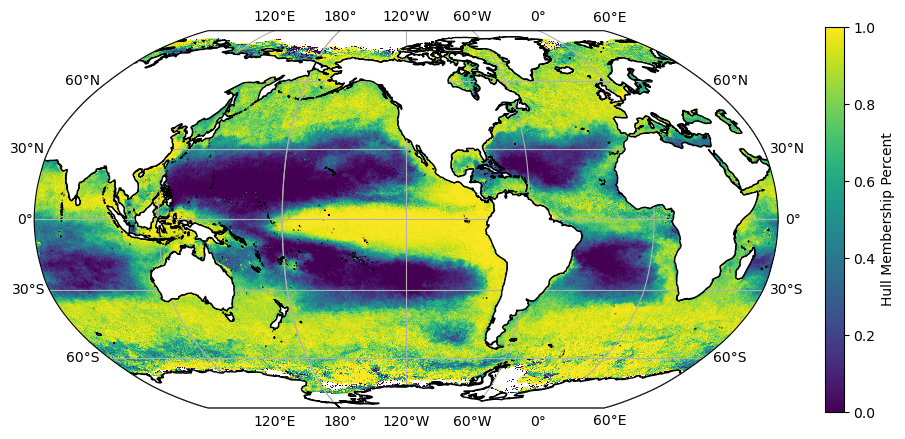

In [63]:
subplot_kws = dict(projection=crs.Robinson(central_longitude=-120), facecolor='white')
fig, ax = plt.subplots(figsize=(12,5), subplot_kw=subplot_kws)
ax.coastlines(resolution='10m')
# ax.set_ylim(34,45)
# ax.set_xlim(-80,-60)

ds.count_map_normalized.plot(ax=ax, x='lon', y='lat', cmap='viridis', vmin=0,vmax=1, transform=crs.PlateCarree(), cbar_kwargs={'label': "Hull Membership Percent"})
ax.add_feature(cart.feature.LAND, zorder=100, edgecolor='k', facecolor='white')

gl = ax.gridlines(draw_labels=True)

# plt.savefig('global_pace_inhull_3d.png',dpi=300)
# plt.savefig('global_modis_inhull_3d_zero.png',dpi=300)

plt.show()

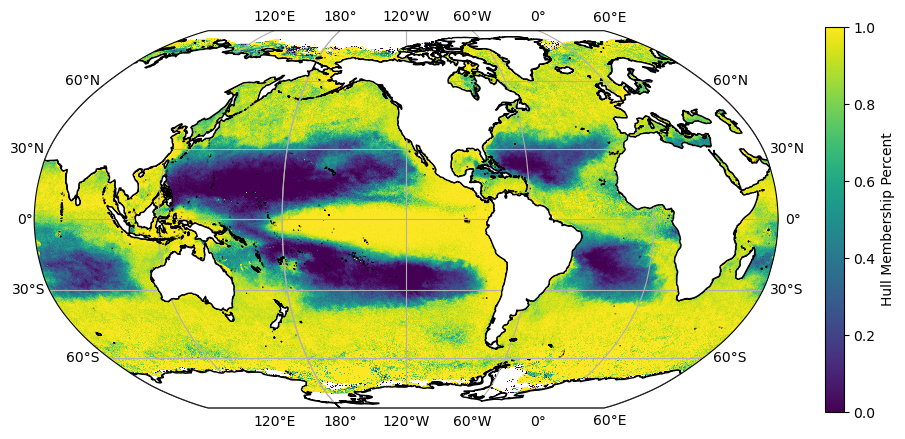

In [39]:
subplot_kws = dict(projection=crs.Robinson(central_longitude=-120), facecolor='white')
fig, ax = plt.subplots(figsize=(12,5), subplot_kw=subplot_kws)
ax.coastlines(resolution='10m')
# ax.set_ylim(34,45)
# ax.set_xlim(-80,-60)

ds.count_map_normalized.plot(ax=ax, x='lon', y='lat', cmap='viridis', vmin=0,vmax=1, transform=crs.PlateCarree(), cbar_kwargs={'label': "Hull Membership Percent"})
ax.add_feature(cart.feature.LAND, zorder=100, edgecolor='k', facecolor='white')

gl = ax.gridlines(draw_labels=True)

# plt.savefig('global_pace_inhull.png',dpi=300)
# plt.savefig('global_modis_inhull_zero.png',dpi=300)

plt.show()

## open the biomes files

In [104]:
biomes = xr.open_dataset('data/Time_Varying_Biomes.nc')

In [105]:
biomes_interp = biomes.MeanBiomes.interp(lon=ds.lon, lat=ds.lat)

1


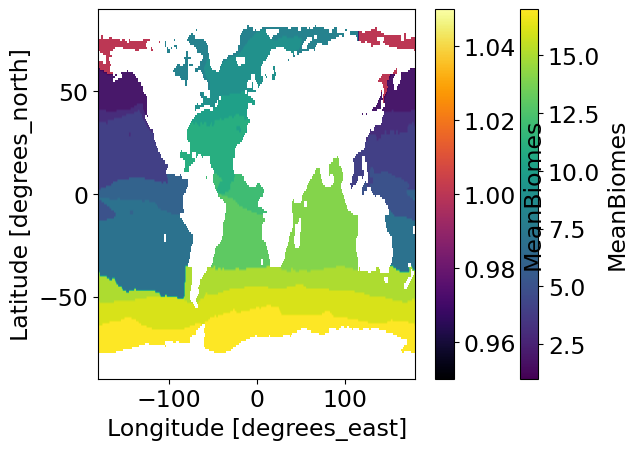

2


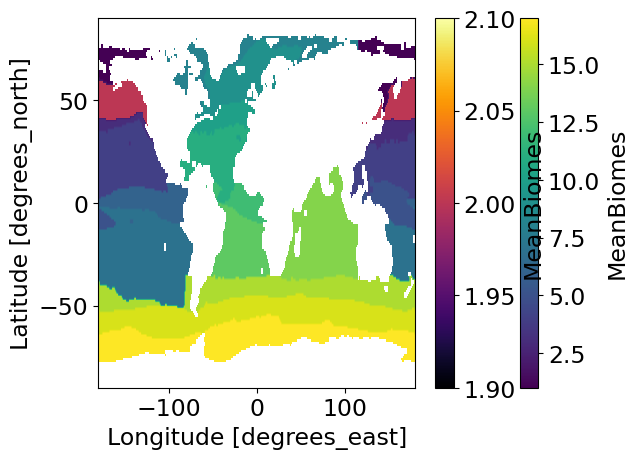

3


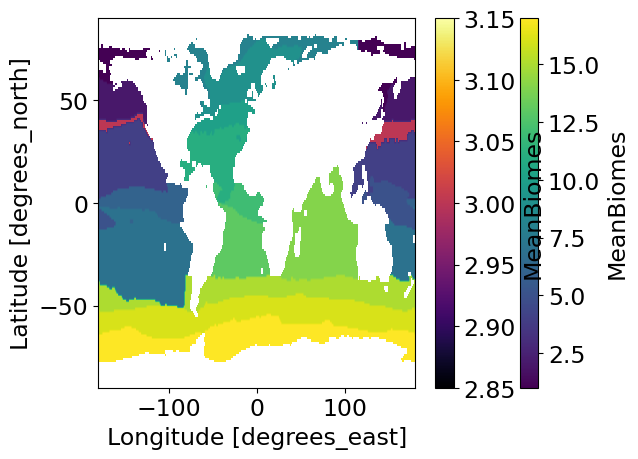

4


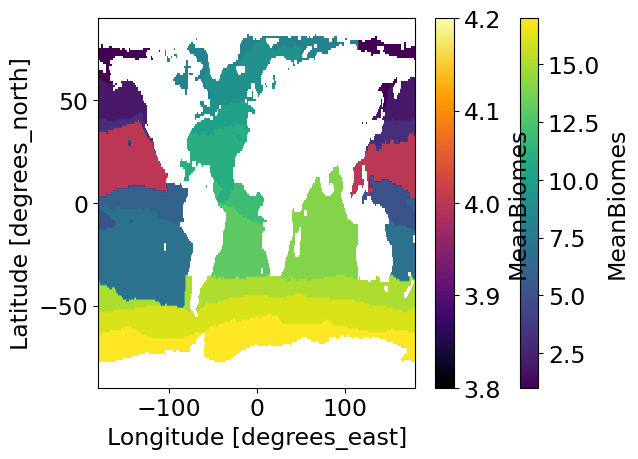

5


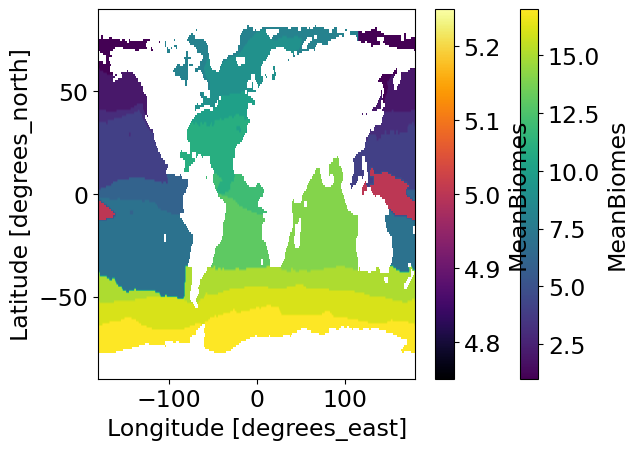

6


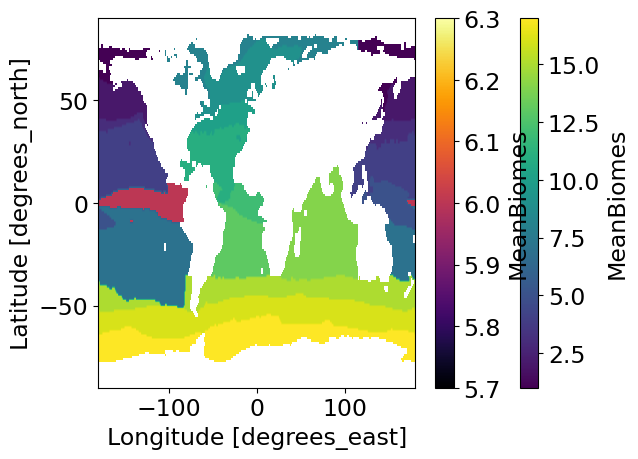

7


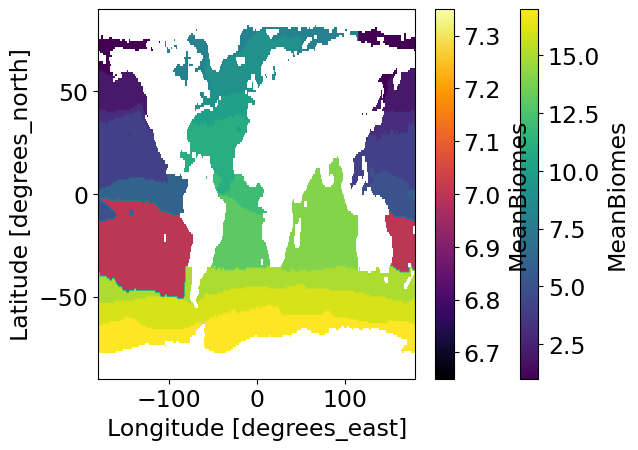

8


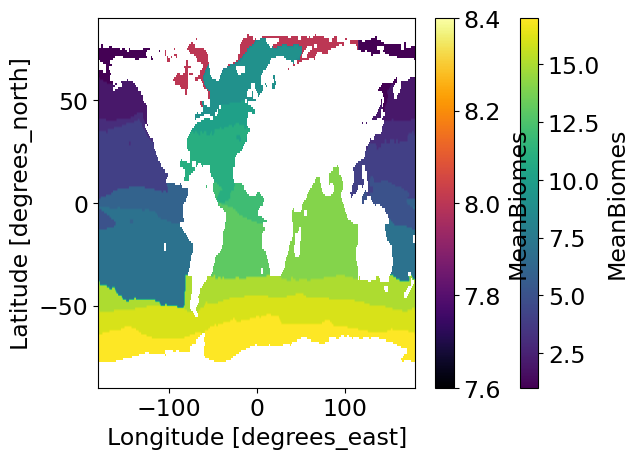

9


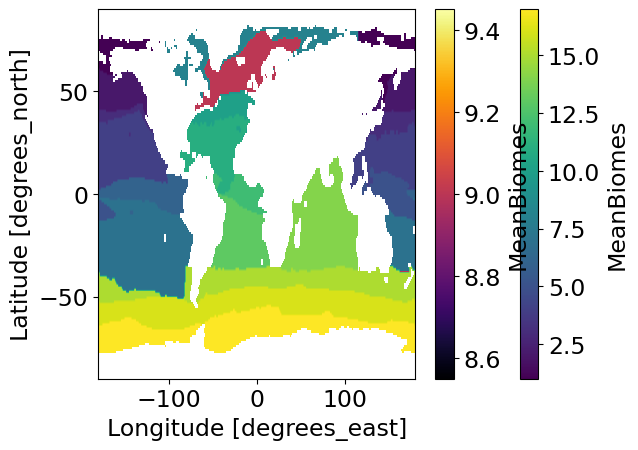

10


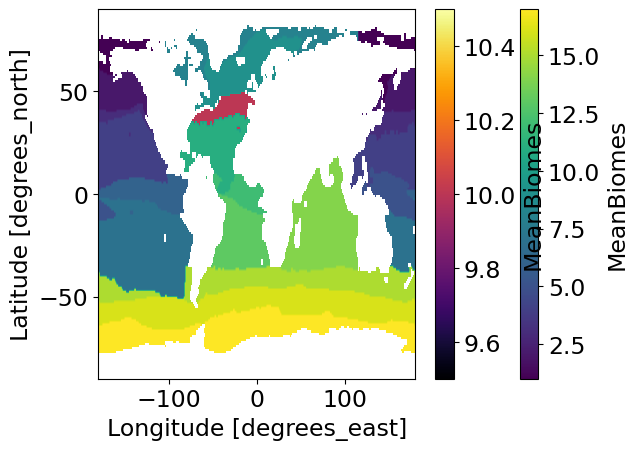

11


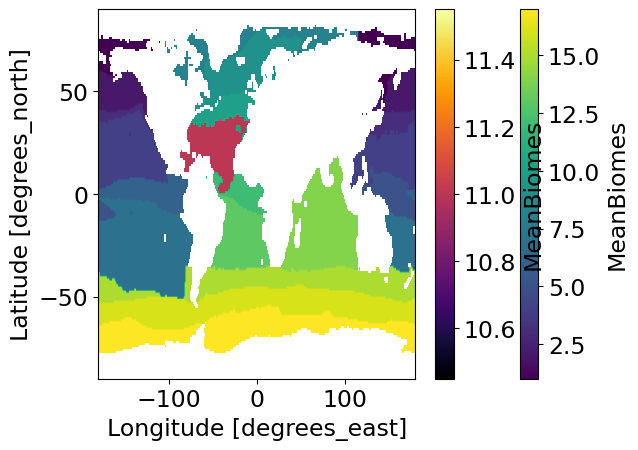

12


In [ ]:
for j in range(1,18):
    print(j)
    biomes_interp.plot(x='lon',y='lat')
    biomes_interp.where(biomes_interp==j).plot(x='lon',y='lat',cmap='inferno')
    plt.show()

In [106]:
cm = plt.get_cmap("tab20")
cm.set_bad("red", alpha=0)

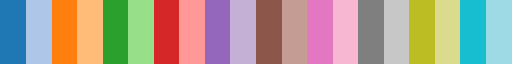

In [107]:
cm

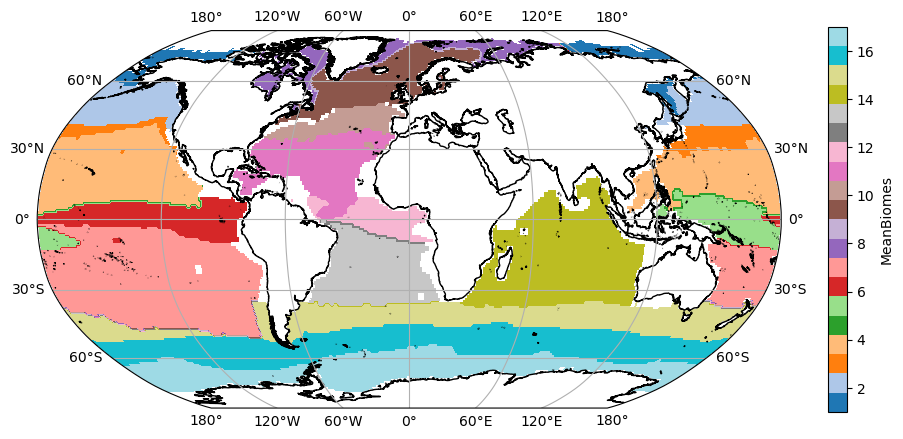

In [76]:
fig, ax = plt.subplots(figsize=(12,5), subplot_kw=dict(projection=crs.Robinson()))
ax.coastlines(resolution='10m')

biomes_interp.plot(ax=ax, x='lon',y='lat',cmap=cm, transform=crs.PlateCarree())
gl = ax.gridlines(draw_labels=True)

# ax.add_feature(cart.feature.LAND, zorder=100, edgecolor='k', facecolor='white')

plt.savefig('ocean_biomes.png',dpi=300)

plt.show()

In [108]:
import warnings
warnings.filterwarnings("ignore")

In [109]:
plt.rcParams.update({'font.size': 17})

1


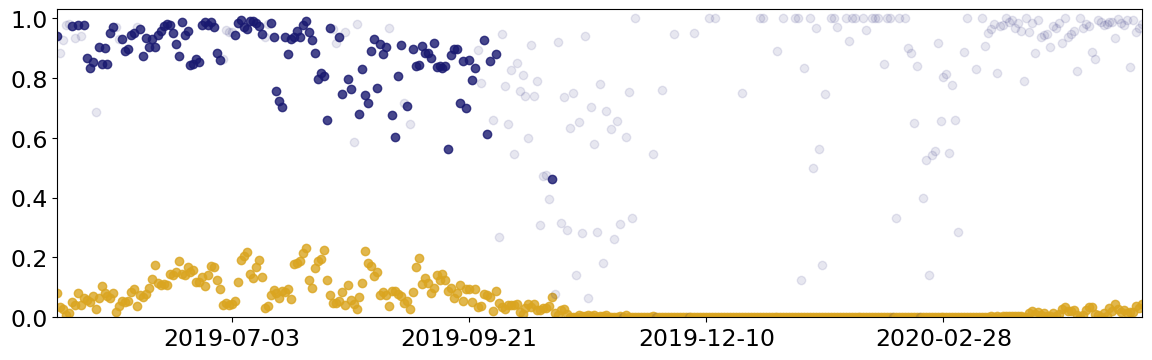

2


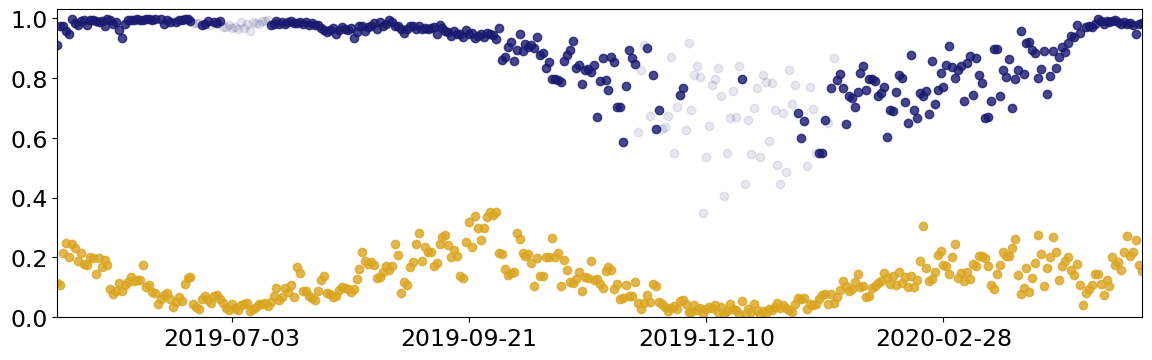

3


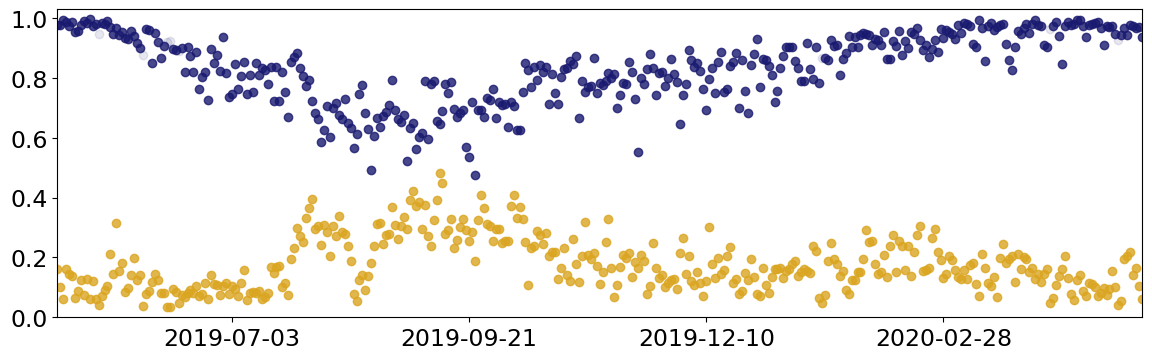

4


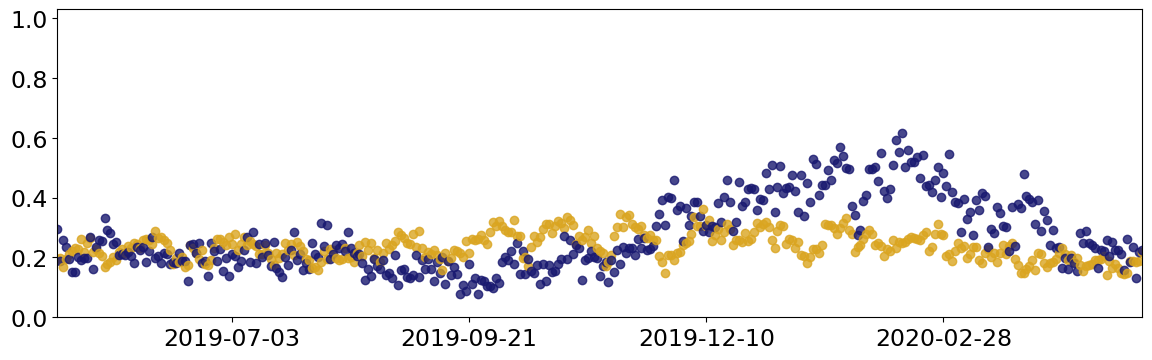

5


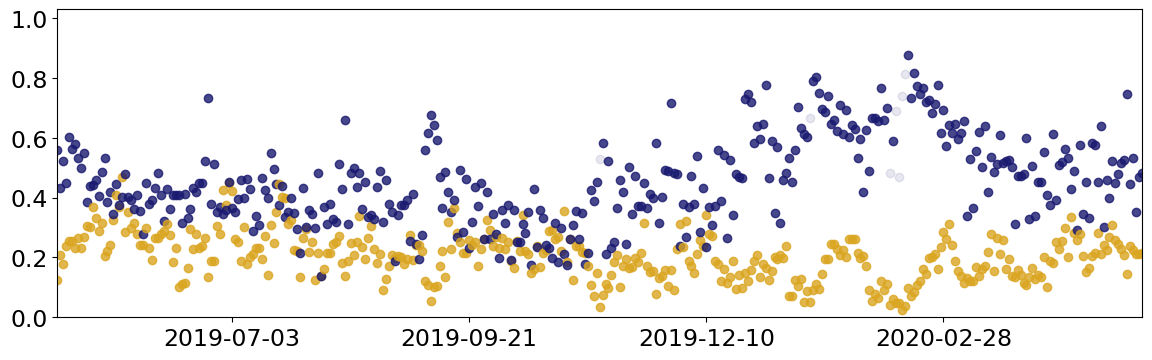

6


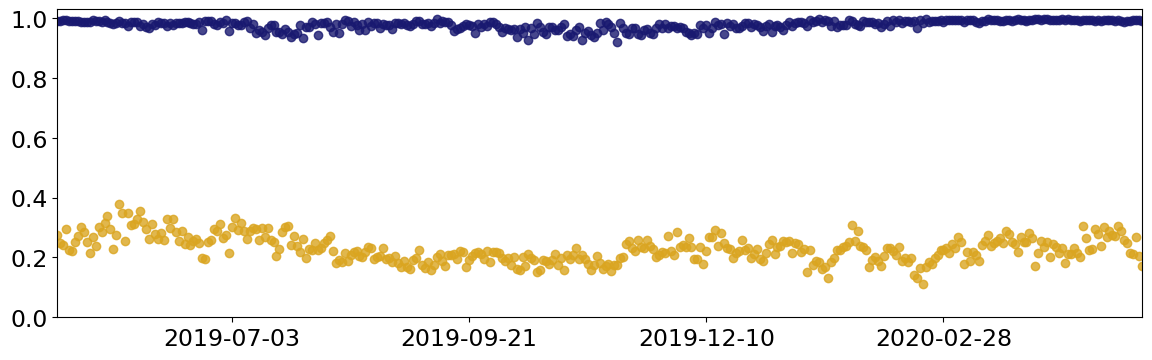

7


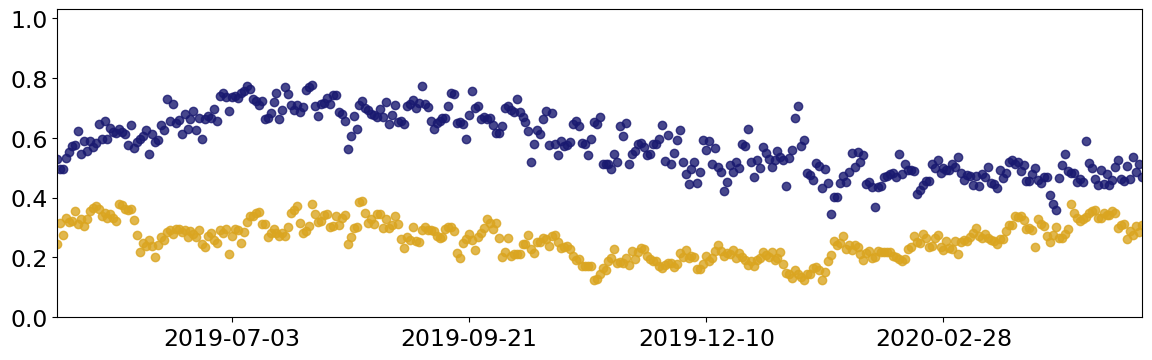

8


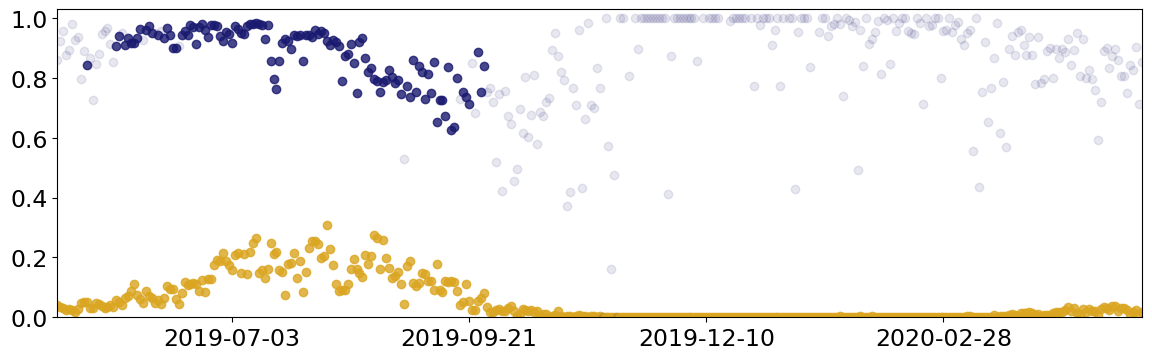

9


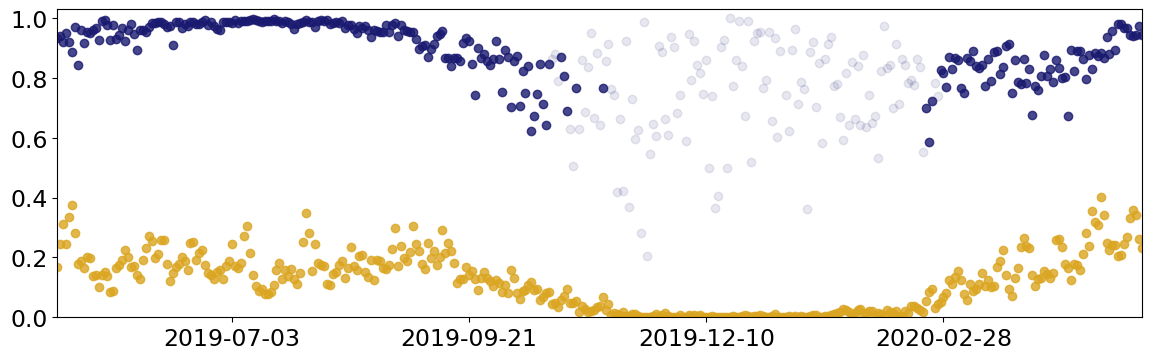

10


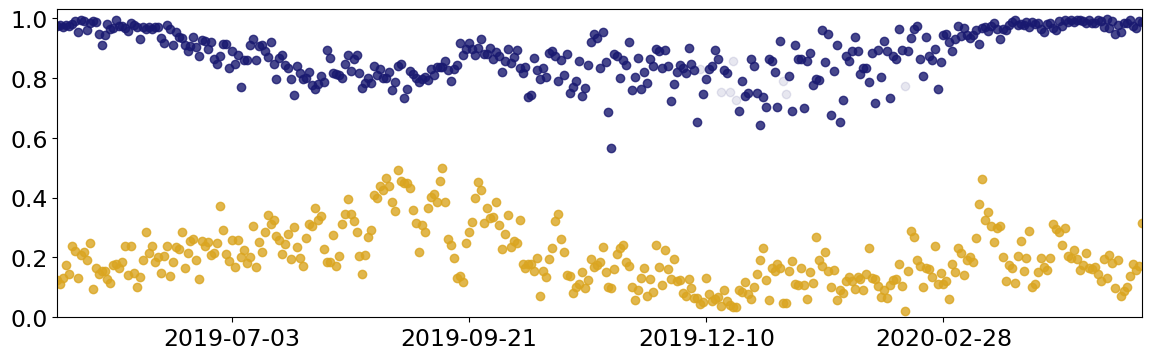

11


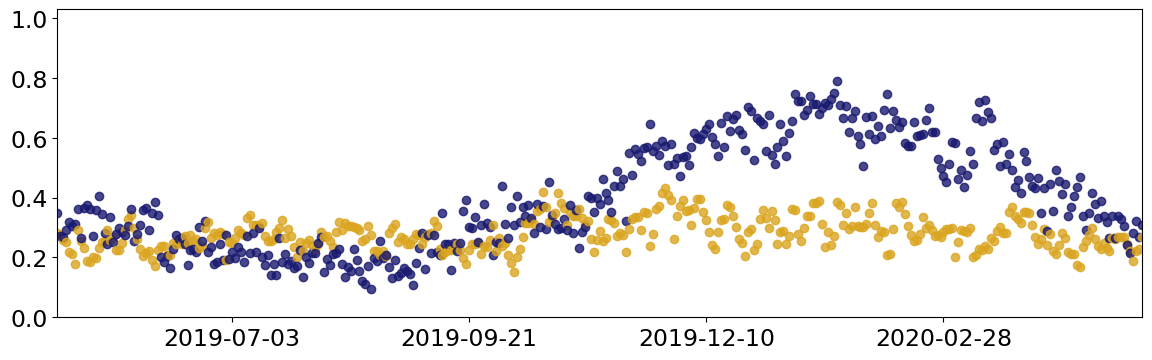

12


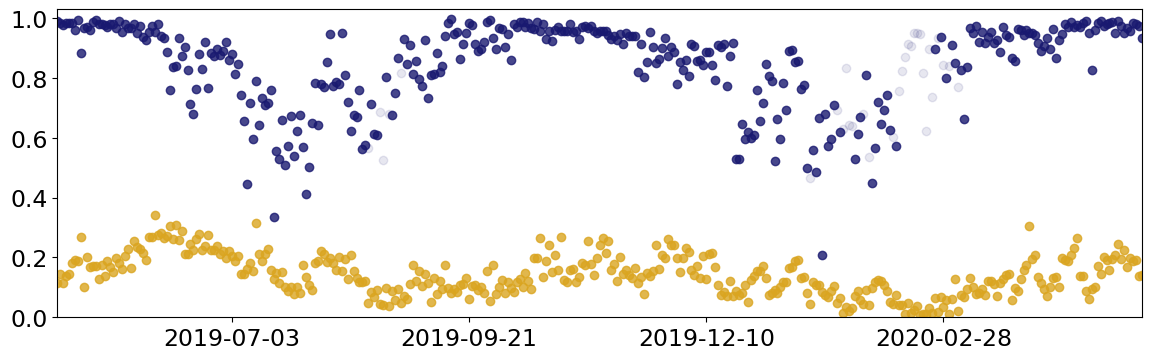

13


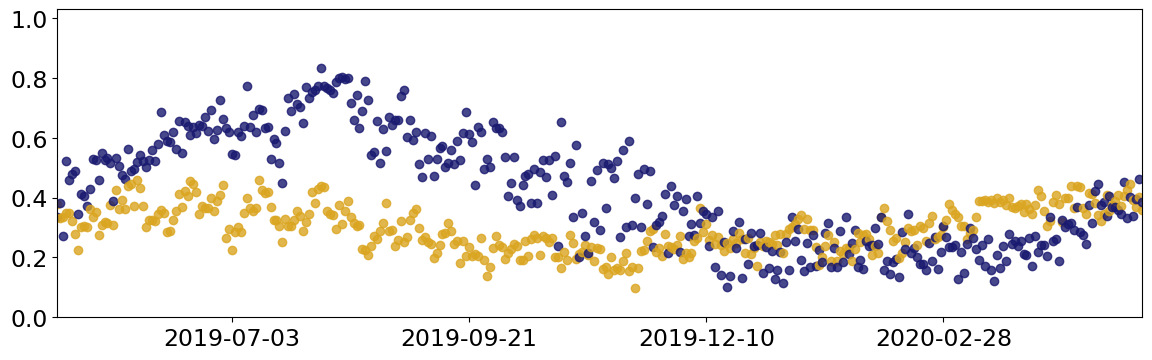

14


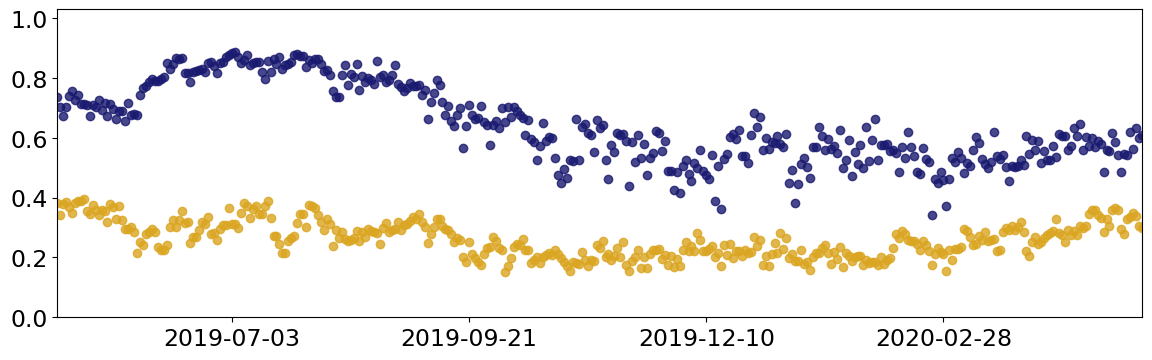

15


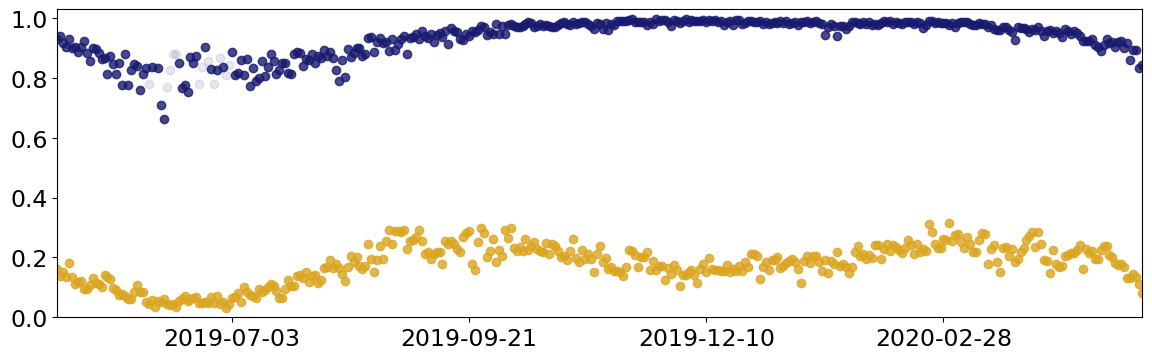

16


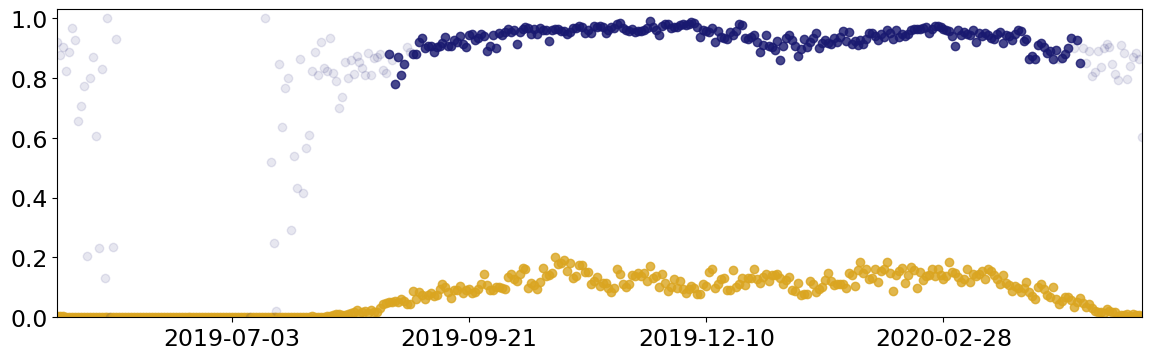

17


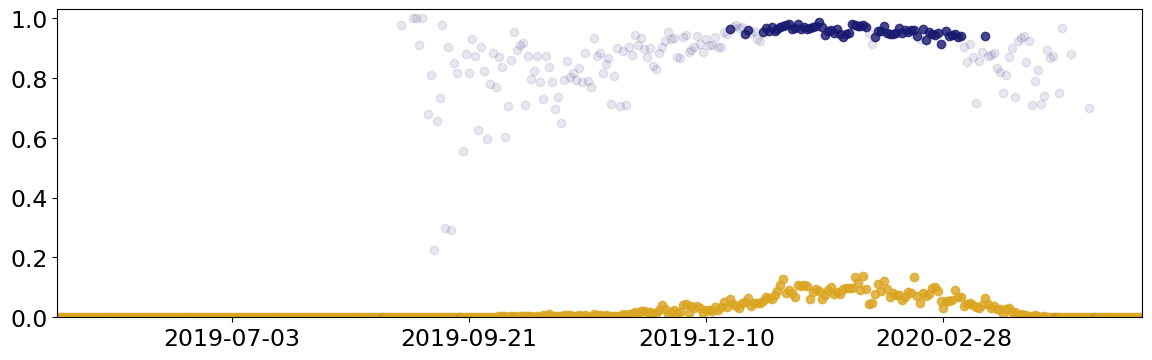

In [111]:
for j in range(1,18):
    print(j)
    # biomes_interp.plot(x='lon',y='lat')
    # biomes_interp.where(biomes_interp==j).plot(x='lon',y='lat',cmap='inferno')
    # plt.show()
    
    fig, ax = plt.subplots(figsize=(14,4))
    # ax2 = ax.twinx()
    
    for i in range(len(count_map_ndims)):
        col = 'k'
        ds['counts'] = (('lat', 'lon'), np.array(nonnan_map_ndims[i]))
        # print(ds.counts.where(biomes_interp==j).sum())
        # if ds.counts.where(biomes_interp==j).sum() < 5000:
        #     print('under 5000 pixels')
        #     continue
        non_nan_sum = ds.counts.where(biomes_interp==j).sum()
        percent_available = non_nan_sum/ds.ones.where(biomes_interp==j).sum()
        ax.scatter(datetimes[i], percent_available,c='goldenrod',alpha=.8)
        # if there are less than 5% of the pixels in a region or less than 1000 pixels let's flag it
        alpha=.8
        if percent_available < 0.05:
            col = 'red'
            alpha = .1
        if non_nan_sum < 1000:
            col = 'red'
            alpha = .1
        ds['counts'] = (('lat', 'lon'), np.array(count_map_ndims[i])/np.array(nonnan_map_ndims[i]))
        # ds.counts.where(biomes_interp==4).plot(x='lon',y='lat')
    
        ax.scatter(datetimes[i], ds.counts.where(biomes_interp==j).mean(),alpha=alpha,c='midnightblue')
    
    ax.set_xlim(datetimes[0],datetimes[-1])
    ax.set_ylim(0,1.03)
    # ax2.set_ylim(0,1.03)

    # ax.yaxis.label.set_color('black')
    # ax.tick_params(axis='y', colors='black')
    
    # ax2.yaxis.label.set_color('blue')
    # ax2.tick_params(axis='y', colors='blue')

    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

    plt.savefig('figs/rhythm_biome_2d'+str(j)+'_modis.png',dpi=300)

    plt.show()
    print('========================================================================================')